# U-Net Implementation for Image Restoration

This notebook implements a U-Net architecture to restore high-resolution images from degraded inputs.

**Key Steps:**
1.  **Data Loading:** Custom generator yielding patches from `data/raw` (Target) and `data/processed` (Input).
2.  **Architecture:** Simple U-Net with skip connections.
3.  **Training:** L1 Loss optimization using Adam.
4.  **Visualisation:** Reconstruction of full images from generated patches.

In [3]:
import os
import numpy as np
import torch 
from PIL import Image
import random

PATCH_SIZE = 256   
BATCH_SIZE = 16   

ROOT_DIR = os.getcwd()
if os.path.basename(ROOT_DIR) == "notebooks":
    ROOT_DIR = os.path.dirname(ROOT_DIR)

DIR_INPUT = os.path.join(ROOT_DIR, "data", "processed")
DIR_TARGET = os.path.join(ROOT_DIR, "data", "raw")    


def get_patches_from_file(filename):
    """Extracts image patches from the file"""

    path_x = os.path.join(DIR_INPUT, filename)
    path_y = os.path.join(DIR_TARGET, filename)
    
    img_x = Image.open(path_x).convert('RGB')
    img_y = Image.open(path_y).convert('RGB')
    
    arr_x = np.array(img_x) / 255.0
    arr_y = np.array(img_y) / 255.0
    
    h, w, _ = arr_x.shape
    patches_x, patches_y = [], []
    
    stride = PATCH_SIZE 
    
    for y in range(0, h, stride):
        for x in range(0, w, stride):
            x_start = min(x, w - PATCH_SIZE)
            y_start = min(y, h - PATCH_SIZE)
            
            patch_x = arr_x[y_start : y_start+PATCH_SIZE, x_start : x_start+PATCH_SIZE, :]
            patch_y = arr_y[y_start : y_start+PATCH_SIZE, x_start : x_start+PATCH_SIZE, :]
            
            patches_x.append(patch_x)
            patches_y.append(patch_y)

    # Transpose to (N, C, H, W) for PyTorch  
    px = np.array(patches_x).transpose(0, 3, 1, 2)
    py = np.array(patches_y).transpose(0, 3, 1, 2)
            
    return px, py

### Dataset Statistics
Calculating available training patches based on the paired images found in the directories.
> **Note:** The statistics below reflect the sample dataset. The full training was performed on ~37K patches.

In [65]:
import math
import os
from PIL import Image

def list_images(folder):
    exts = (".png", ".jpg", ".jpeg")
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])

def patches_per_image(path, patch_size=256):
    with Image.open(path) as im:
        w, h = im.size
    return math.ceil(w / patch_size) * math.ceil(h / patch_size)


input_files = list_images(DIR_INPUT)
target_files = set(list_images(DIR_TARGET))

paired_files = [f for f in input_files if f in target_files]
missing_targets = len(input_files) - len(paired_files)


counts = [patches_per_image(os.path.join(DIR_INPUT, f), PATCH_SIZE) for f in paired_files]

print(f"Input files:  {len(input_files)}")
print(f"Paired files: {len(paired_files)} (Ready for training)")

if missing_targets > 0:
    print(f"Missing targets: {missing_targets} (Ignored)")

if counts:
    print("-" * 30)
    print(f"Patches per image: Min={min(counts)}, Avg={sum(counts)/len(counts):.1f}, Max={max(counts)}")
    print(f"Total patches in dataset: {sum(counts)}")

Input files:  15
Paired files: 15 (Ready for training)
------------------------------
Patches per image: Min=40, Avg=50.7, Max=64
Total patches in dataset: 760


In [ ]:
def data_generator():
    """Generator danych, który losowo miesza listę plików i zwraca batch'e patchy."""
    all_files = [f for f in os.listdir(DIR_INPUT) if f.endswith(('.png', '.jpg'))]
    
    while True:
        random.shuffle(all_files) 
        
        for file in all_files:

            x_patches, y_patches = get_patches_from_file(file)
            
            num_patches = len(x_patches)
            for i in range(0, num_patches, BATCH_SIZE):
                bx = x_patches[i : i+BATCH_SIZE]
                by = y_patches[i : i+BATCH_SIZE]
                
                if len(bx) > 0:

                    yield torch.tensor(bx, dtype=torch.float32), torch.tensor(by, dtype=torch.float32)

In [34]:
import torch
print(f"Pytorch version: {torch.__version__}")
print(f"Is CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

Pytorch version: 2.10.0+cu130
Is CUDA available?: True
GPU: NVIDIA GeForce RTX 5070


## Model Architecture: Residual U-Net

We implement a lightweight **U-Net** architecture with a global residual connection.

**Key Components:**
1.  **Encoder:** Extracts features and reduces spatial dimensions using MaxPool.
2.  **Bottleneck:** Processes the most abstract features at the lowest resolution.
3.  **Decoder:** Upsamples features and concatenates them with high-resolution details from the Encoder (Skip Connections).
4.  **Global Residual Connection:** The model learns the difference between the input and the target.
    * Formula: `Output = Input + Predicted_Correction`


In [6]:
import torch.nn as nn


class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())
        
        # Decoder 
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2 = nn.Sequential(nn.Conv2d(256 + 128, 128, 3, padding=1), nn.ReLU()) 
        
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1 = nn.Sequential(nn.Conv2d(128 + 64, 64, 3, padding=1), nn.ReLU())   
        
        self.final = nn.Conv2d(64, 3, 1) 

    def forward(self, x):
        identity = x 
        
        # Encoding
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # Bottleneck
        b = self.bottleneck(p2)
        
        # Decoding
        d2 = self.up2(b)
        d2 = torch.cat((d2, e2), dim=1) #Skip connection from e2
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1) #Skip connection from e1
        d1 = self.dec1(d1)
        
        # Global Residual Learning
        residual = self.final(d1)
        out = identity + residual 
        
        return torch.clamp(out, 0, 1) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleUNet().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 1,698,755


In [ ]:
def one_epoch_batches():
    files = list(paired_files)
    random.shuffle(files)

    for file in files:
        x_patches, y_patches = get_patches_from_file(file)

        # Batches from a single image
        for i in range(0, len(x_patches), BATCH_SIZE):
            bx = x_patches[i:i+BATCH_SIZE]
            by = y_patches[i:i+BATCH_SIZE]
            if len(bx) > 0:
                yield torch.tensor(bx, dtype=torch.float32), torch.tensor(by, dtype=torch.float32)


### Training Loop
> **Note:** The output below represents the original training logs on the full dataset (800 images and ~37k patches).

In [ ]:

import time
import torch.optim as optim

EPOCHS = 10
optimizer = optim.Adam(model.parameters(), lr=0.0002)
criterion = nn.L1Loss()

print("Start treningu...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    steps = 0
    t0 = time.time()

    for step, (inputs, targets) in enumerate(one_epoch_batches(), start=1):

        if step == 1:
            print(f"[epoch {epoch+1}] pierwszy batch shape: {tuple(inputs.shape)} na device={device}")

        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        steps += 1

        # print progress per 50 steps
        if step % 50 == 0:
            dt = time.time() - t0
            print(f"[epoch {epoch+1}] step={step} avg_loss={epoch_loss/steps:.6f} time={dt:.1f}s")

    dt = time.time() - t0
    print(f"Epoka {epoch+1}/{EPOCHS} zakończona: avg_loss={epoch_loss/max(1,steps):.6f}, kroki={steps}, czas={dt:.1f}s")
    torch.save(model.state_dict(), os.path.join("models", "unet_model.pth"))

In [35]:
model_path = os.path.join(ROOT_DIR, "models", "unet_model.pth")
model = SimpleUNet().to(device)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print(f"Model loaded successfully!")
    

Model loaded successfully!


# Visualization

In this section, we evaluate the model's performance on validation samples. 
<br>We analyze the results on **Patch-level** (Examining fine details on individual 256x256px patch) and **Full Image Reconstruction** (Verifying the entire reconstructed image and identifying problematic areas using an Error Map)


### Patch-level Comparison

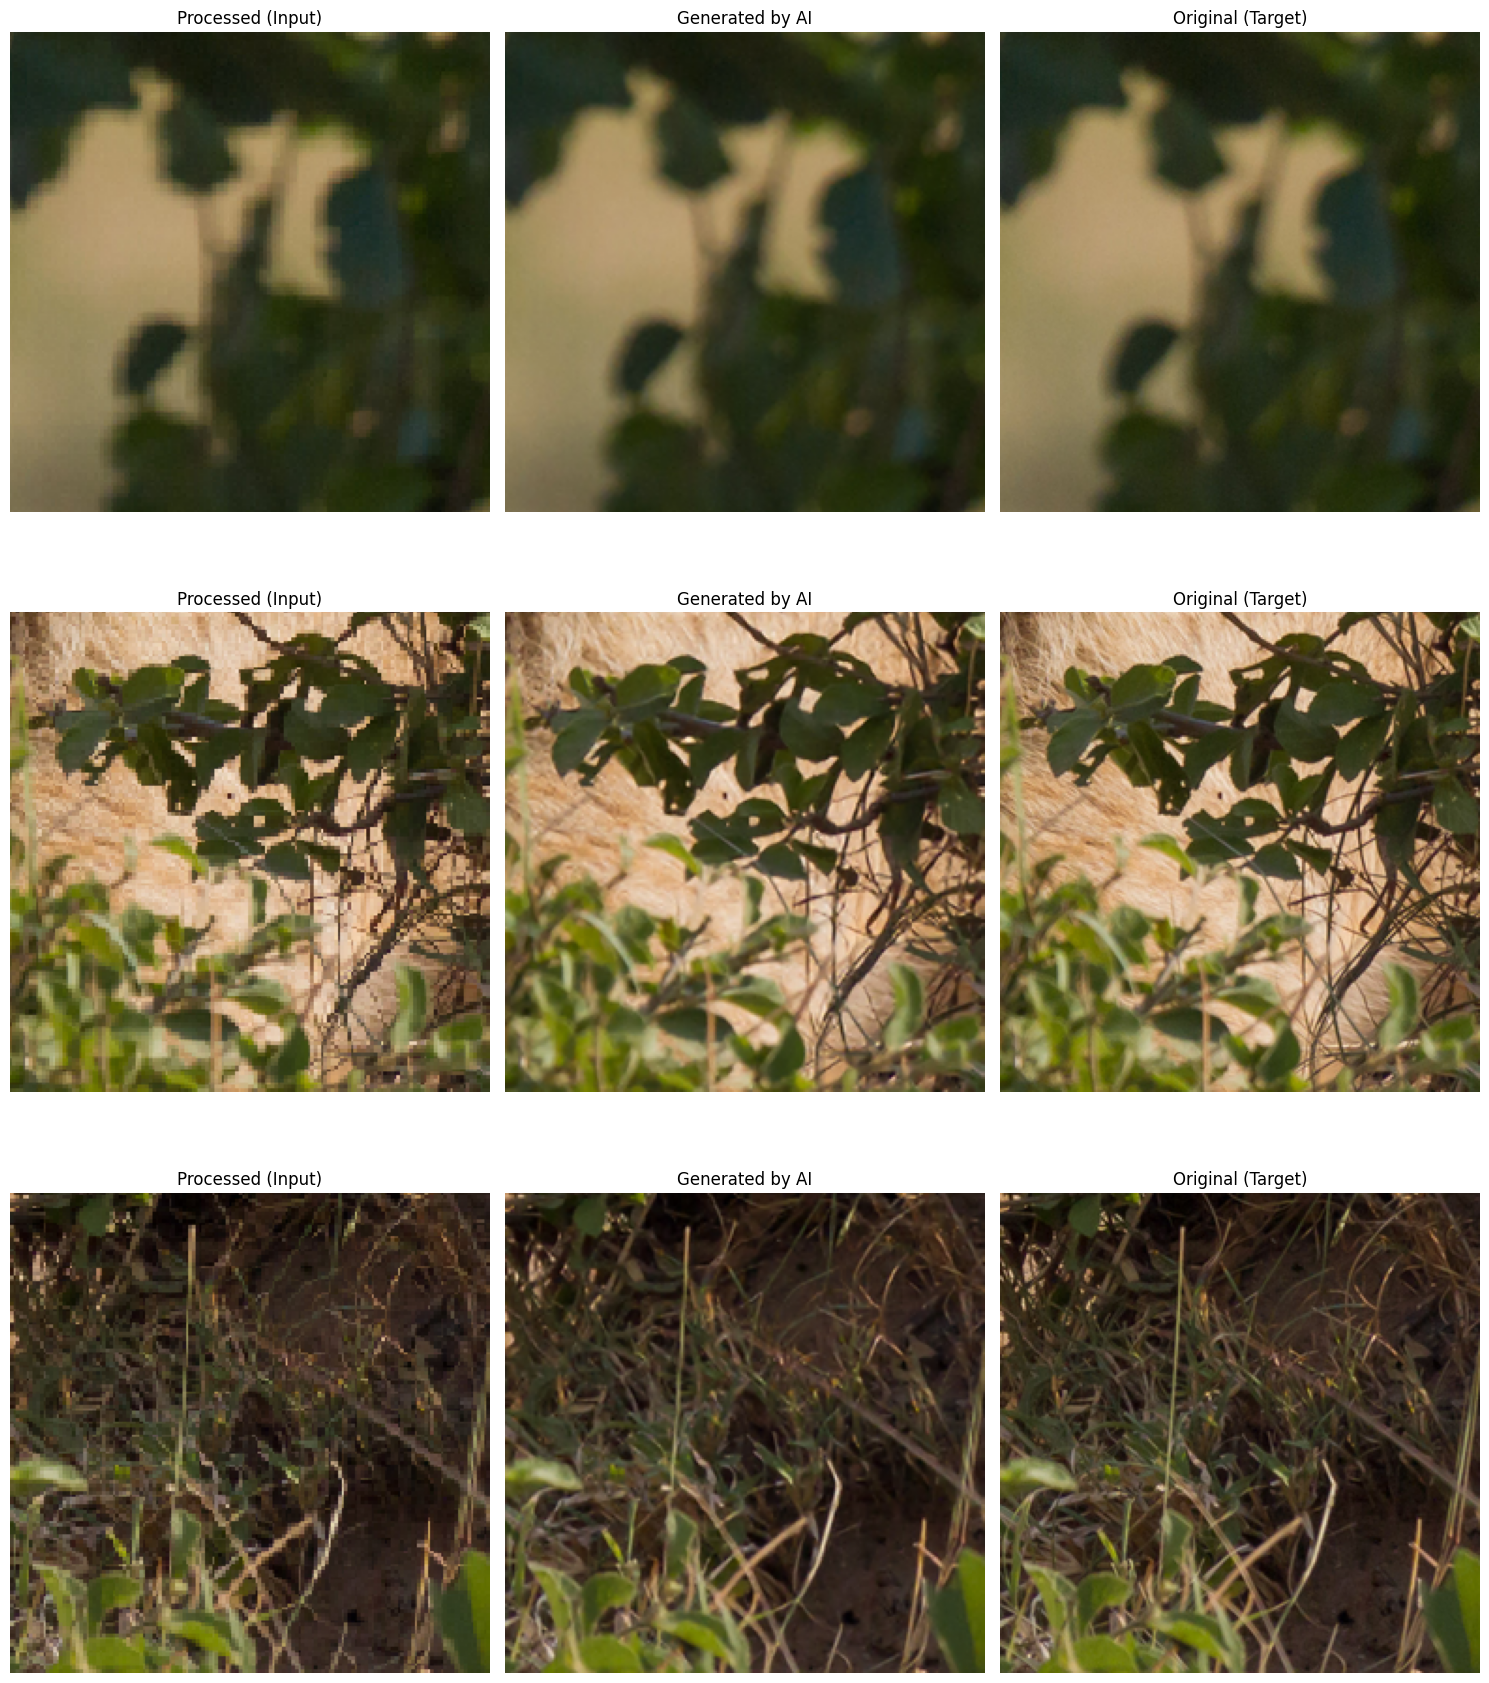

In [123]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def show_patches_comparison(filename, model, num_samples=3):
    """
    Takes patches from a specific file, runs them through the model, and displays the results.
    """
    try:
        inputs_np, targets_np = get_patches_from_file(filename)
    except FileNotFoundError:
        print(f"Error: {filename} file not found.")
        return

    total_patches = len(inputs_np)    
    real_samples = min(num_samples, total_patches)

    np.random.seed(88)  
    indices = np.random.choice(total_patches, real_samples, replace=False)
    selected_inputs = inputs_np[indices]
    selected_targets = targets_np[indices]

    inputs = torch.tensor(selected_inputs, dtype=torch.float32).to(device)
    targets = torch.tensor(selected_targets, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        preds = model(inputs)

    # Drawing
    plt.figure(figsize=(15, 6 * real_samples))
    for i in range(real_samples):
        img_in = inputs[i].cpu().permute(1, 2, 0).numpy()
        img_out = preds[i].cpu().permute(1, 2, 0).numpy()
        img_tgt = targets[i].cpu().permute(1, 2, 0).numpy()
        
        plt.subplot(real_samples, 3, i*3 + 1)
        plt.imshow(img_in)
        plt.title(f"Processed (Input)")
        plt.axis("off")
        
        plt.subplot(real_samples, 3, i*3 + 2)
        plt.imshow(img_out)
        plt.title("Generated by AI")
        plt.axis("off")
        
        plt.subplot(real_samples, 3, i*3 + 3)
        plt.imshow(img_tgt)
        plt.title("Original (Target)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
show_patches_comparison("0683.png", model, num_samples=3)

### Full Image Comparison

In [ ]:
import torchvision.transforms.functional as TF

def reconstruct_full_images(filename, model, patch_size=256):
    """
    Reconstructs the full image from patches and visualizes the results.
    """
    path_in = os.path.join(DIR_INPUT, filename)
    path_tar = os.path.join(DIR_TARGET, filename)
    
    if not os.path.exists(path_in) or not os.path.exists(path_tar):
        print(f"Error: File {filename} not found.")
        return
        
    img_in = Image.open(path_in).convert('RGB')
    img_tar = Image.open(path_tar).convert('RGB')
    w, h = img_in.size
    
    reconstructed = Image.new("RGB", (w, h))
    
    # Helper for sliding window coords
    def get_coords(length, p_size):
        coords = []
        x = 0
        while x + p_size <= length:
            coords.append(x)
            x += p_size
        if length % p_size != 0:
            coords.append(length - p_size)
        return coords

    x_coords = get_coords(w, patch_size)
    y_coords = get_coords(h, patch_size)
    
    model.eval()
    with torch.no_grad():
        for y in y_coords:
            for x in x_coords:
                patch = img_in.crop((x, y, x + patch_size, y + patch_size))
                input_tensor = TF.to_tensor(patch).unsqueeze(0).to(device)
                output_tensor = model(input_tensor).squeeze(0).cpu()
                output_patch = TF.to_pil_image(output_tensor)
                reconstructed.paste(output_patch, (x, y))

    return img_in, reconstructed, img_tar   

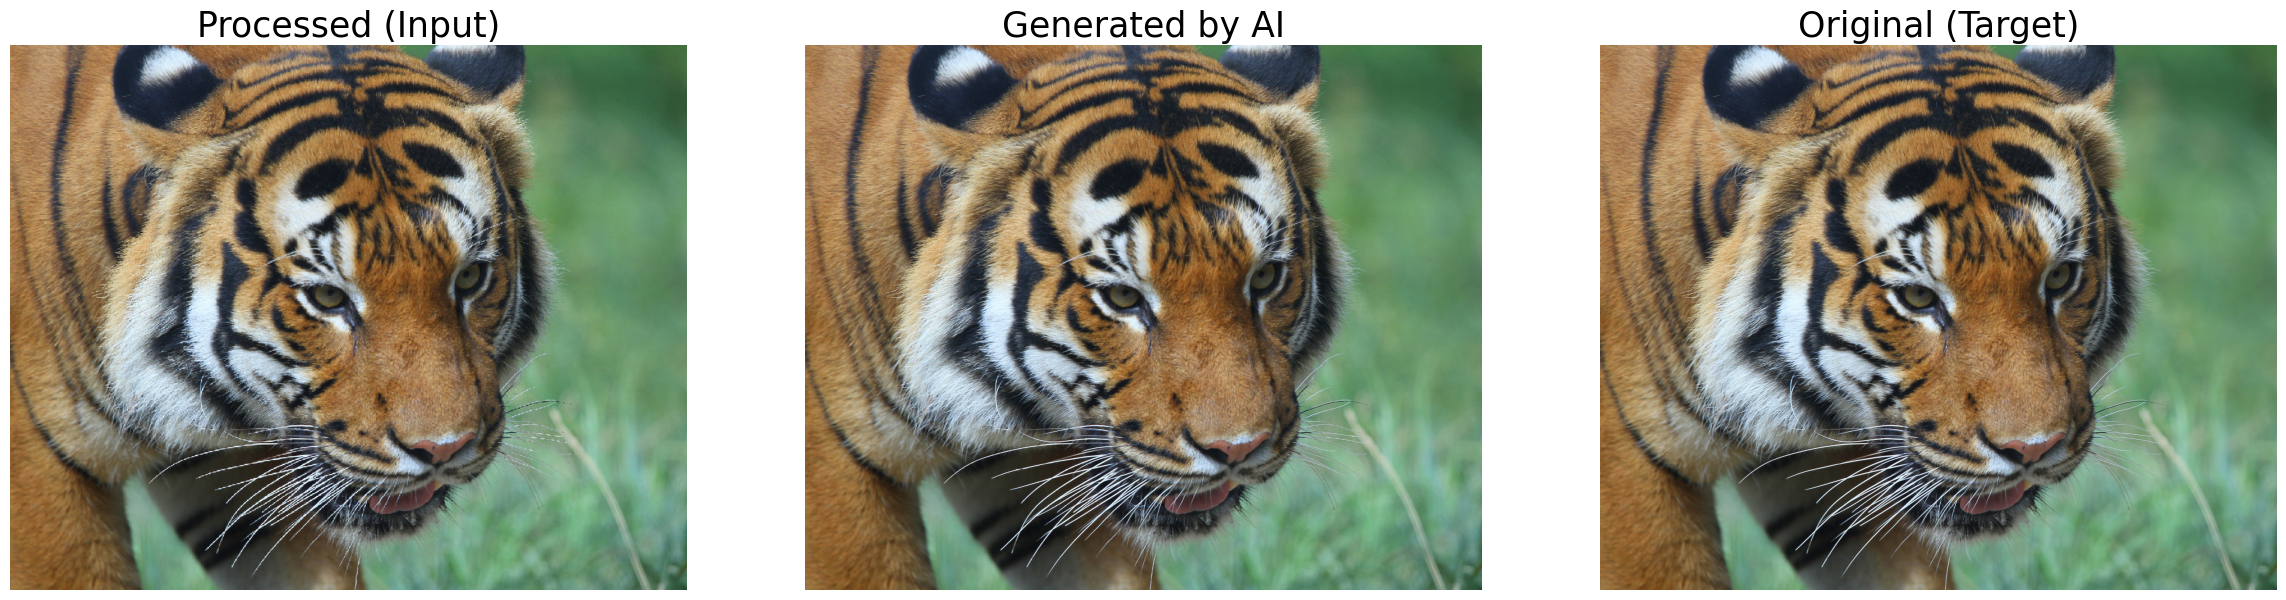

In [105]:
random.seed(10)
test_image = random.choice(paired_files)
img_in, reconstructed, img_tar = reconstruct_full_images(test_image, model)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].imshow(img_in)
axes[0].set_title("Processed (Input)", fontsize=25)
axes[0].axis('off')

axes[1].imshow(reconstructed)
axes[1].set_title("Generated by AI", fontsize=25)
axes[1].axis('off')

axes[2].imshow(img_tar)
axes[2].set_title("Original (Target)", fontsize=25)
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Error Map 

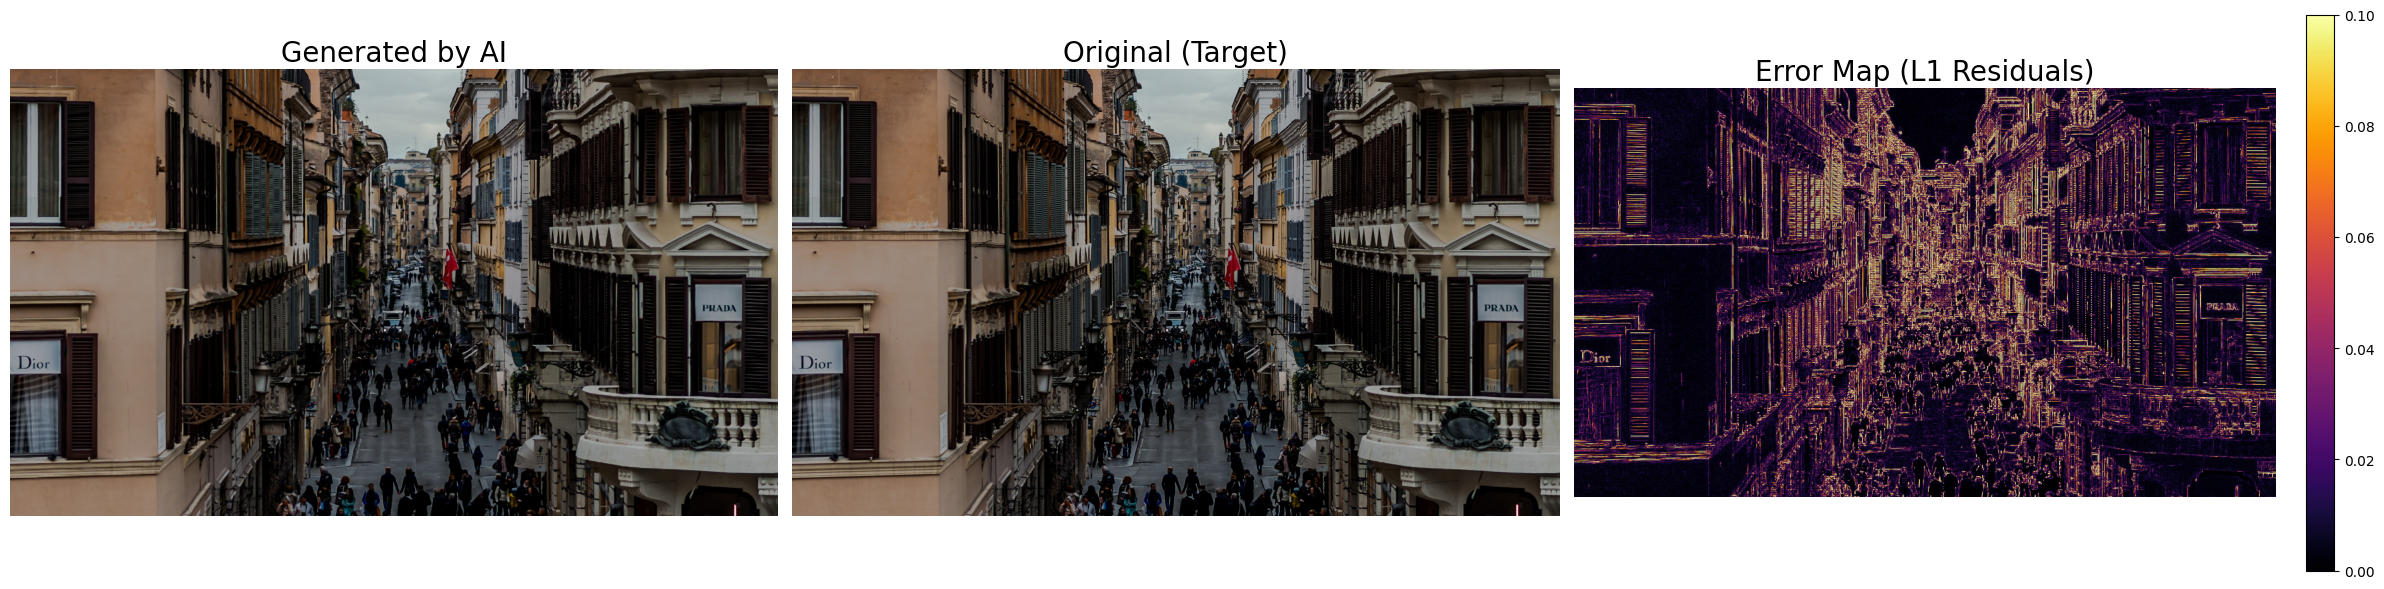

In [ ]:
img_in, reconstructed, img_tar = reconstruct_full_images("0583.png", model)

rec_np = np.array(reconstructed) / 255.0
tar_np = np.array(img_tar) / 255.0
error_map = np.abs(tar_np - rec_np).mean(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].imshow(reconstructed)
axes[0].set_title("Generated by AI", fontsize=20)
axes[0].axis('off')

axes[1].imshow(img_tar)
axes[1].set_title("Original (Target)", fontsize=20)
axes[1].axis('off')

im = axes[2].imshow(error_map, cmap='inferno', vmin=0, vmax=0.1)
axes[2].set_title("Error Map (L1 Residuals)", fontsize=20)
axes[2].axis('off')

plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
